In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df = pd.read_csv("Merging.csv")
df.head()

,Unnamed: 0,text,label
0,0,I think the issue of elderly drivers is a comp...,1
1,1,I agree that television violence has a negativ...,1
2,2,I understand the concerns of people who are op...,1
3,3,"Dear Principal, I am writing to you today to e...",1
4,4,"Yes, there is a cause that I actively support:...",1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2961 entries, 0 to 2960
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  2961 non-null   int64 
 1   text        2961 non-null   object
 2   label       2961 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 69.5+ KB


In [ ]:
df['label'].value_counts()

,count
label,
0,1927
1,1033
2,1


In [ ]:
df['label'] == 2

,label
0,False
1,False
2,False
3,False
4,False
...,...
2956,False
2957,False
2958,False
2959,False


In [ ]:
X = df['text']
y = df['label']

In [ ]:
y == y[2]

,label
0,True
1,True
2,True
3,True
4,True
...,...
2956,False
2957,True
2958,True
2959,True


In [ ]:
# Make sure label is integer type
df["label"] = pd.to_numeric(df["label"], errors="coerce")

# Drop rows where label == 2
df = df[df["label"] != 2].reset_index(drop=True)

print("✅ Cleaned dataset shape:", df.shape)
print(df["label"].value_counts())


✅ Cleaned dataset shape: (2960, 3)
label
0    1927
1    1033
Name: count, dtype: int64


In [ ]:
df["label"].value_counts()

,count
label,
0,1927
1,1033


In [ ]:
import nltk
import re
import string

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords


def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words("english"))
    tokens = [WordNetLemmatizer().lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
X = df['text']
y = df['label']

In [ ]:
X = X.apply(clean_text)

In [ ]:
clean_view = pd.DataFrame({
    "Text": df['text'][:5],
    "Clean Text": X[:5]
})
clean_view.head()

,Text,Clean Text
0,I think the issue of elderly drivers is a comp...,think issue elderly driver complex one valid a...
1,I agree that television violence has a negativ...,agree television violence negative effect soci...
2,I understand the concerns of people who are op...,understand concern people opposed animal testi...
3,"Dear Principal, I am writing to you today to e...",dear principal writing today express concern p...
4,"Yes, there is a cause that I actively support:...",yes cause actively support release internation...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X)
X.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "SVC": SVC(),
    "RandomForestClassifier": RandomForestClassifier(),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "ExtraTreeClassifier": ExtraTreeClassifier(),
    "MultinomialNB": MultinomialNB(),
    "BernoulliNB": BernoulliNB(),
    "MLPClassifier": MLPClassifier(max_iter=500),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

for name, model in models.items():
    print("="*20, name, "="*20)
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        score = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        classification = classification_report(y_test, y_pred)

        print(f"Accuracy score : {score:.4f}")
        print("*" * 50)
        print(f"Confusion matrix :\n{cm}")
        print("*" * 50)
        print(f"Classification report:\n{classification}")
        print("*" * 50)
    except Exception as e:
        print(f"X {name} failed: {e}")


==================== LogisticRegression ====================
Accuracy score : 0.9780
**************************************************
Confusion matrix :
[[362  11]
 [  2 217]]
**************************************************
Classification report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       373
           1       0.95      0.99      0.97       219

    accuracy                           0.98       592
   macro avg       0.97      0.98      0.98       592
weighted avg       0.98      0.98      0.98       592

**************************************************
==================== SVC ====================
Accuracy score : 0.9848
**************************************************
Confusion matrix :
[[365   8]
 [  1 218]]
**************************************************
Classification report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       373
           1       0.96 

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:21:56] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy score : 0.9814
**************************************************
Confusion matrix :
[[371   2]
 [  9 210]]
**************************************************
Classification report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       373
           1       0.99      0.96      0.97       219

    accuracy                           0.98       592
   macro avg       0.98      0.98      0.98       592
weighted avg       0.98      0.98      0.98       592

**************************************************


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision (macro)": precision_score(y_test, y_pred, average="macro"),
            "Recall (macro)": recall_score(y_test, y_pred, average="macro"),
            "F1 (macro)": f1_score(y_test, y_pred, average="macro"),
            "Precision (weighted)": precision_score(y_test, y_pred, average="weighted"),
            "Recall (weighted)": recall_score(y_test, y_pred, average="weighted"),
            "F1 (weighted)": f1_score(y_test, y_pred, average="weighted")
        })
    except Exception as e:
        print(f"X {name} failed: {e}")

df_results = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
df_results.head(10)



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:23:09] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),Precision (weighted),Recall (weighted),F1 (weighted)
2,RandomForestClassifier,0.994932,0.996011,0.993151,0.994549,0.994973,0.994932,0.994925
7,MLPClassifier,0.986486,0.984645,0.986448,0.985533,0.986536,0.986486,0.986499
1,SVC,0.984797,0.980935,0.986993,0.983798,0.985184,0.984797,0.984845
8,XGBoost,0.981419,0.983441,0.976771,0.979935,0.981587,0.981419,0.981354
0,LogisticRegression,0.978041,0.973130,0.980688,0.976639,0.978690,0.978041,0.978128
3,DecisionTreeClassifier,0.940878,0.941206,0.931403,0.935899,0.940919,0.940878,0.940546
4,ExtraTreeClassifier,0.932432,0.929751,0.924700,0.927108,0.932239,0.932432,0.932233
5,MultinomialNB,0.856419,0.886229,0.813477,0.832677,0.870507,0.856419,0.849073
6,BernoulliNB,0.817568,0.830914,0.852400,0.816149,0.872019,0.817568,0.820350


In [ ]:
from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in models.items():
    try:
        scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
        cv_results.append({
            "Model": name,
            "Mean CV Accuracy": scores.mean(),
            "Std CV Accuracy": scores.std()
        })
    except Exception as e:
        print(f"X {name} failed: {e}")

df_cv_results = pd.DataFrame(cv_results).sort_values(by="Mean CV Accuracy", ascending=False)
df_cv_results.head(10)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:28:38] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:28:46] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:28:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:28:59] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:29:05] WARNING: /w

,Model,Mean CV Accuracy,Std CV Accuracy
2,RandomForestClassifier,0.969595,0.019699
8,XGBoost,0.968919,0.025875
7,MLPClassifier,0.966892,0.030247
1,SVC,0.961824,0.040295
0,LogisticRegression,0.946622,0.053113
3,DecisionTreeClassifier,0.904392,0.062336
4,ExtraTreeClassifier,0.903378,0.046756
5,MultinomialNB,0.830068,0.066182
6,BernoulliNB,0.797635,0.246284


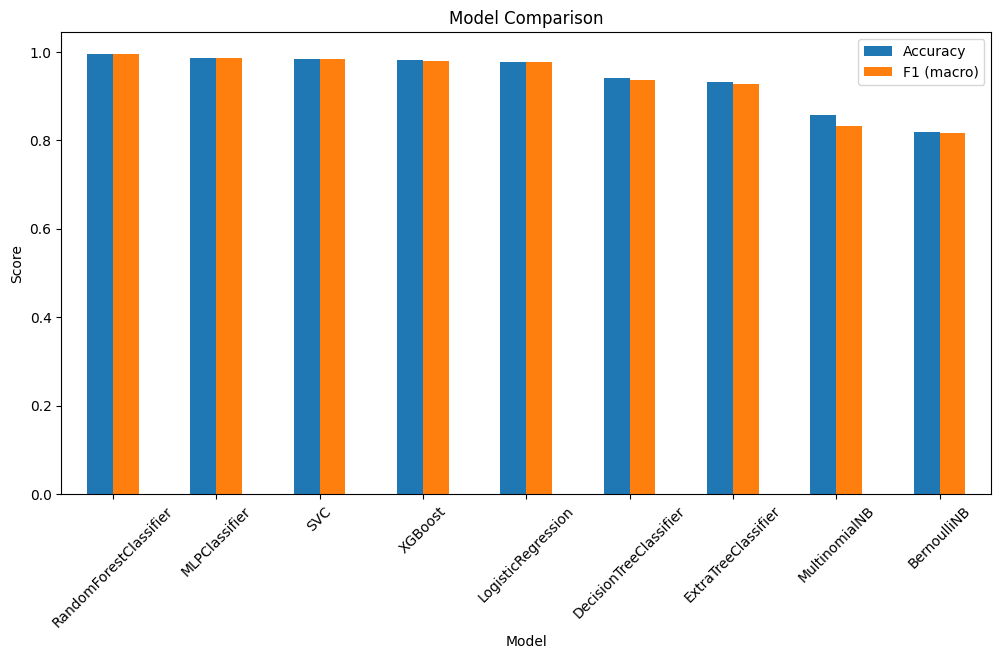

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
df_results.plot(x="Model", y=["Accuracy", "F1 (macro)"], kind="bar", figsize=(12,6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:40:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:40:12] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:40:18] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:40:23] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:40:31] WARNING: /w

                    Model  Accuracy  F1 (macro)
8                 XGBoost  0.968919    0.965383
2  RandomForestClassifier  0.968243    0.967254
7           MLPClassifier  0.967230    0.967205
1                     SVC  0.961824    0.959270
0      LogisticRegression  0.946622    0.943248
3  DecisionTreeClassifier  0.905743    0.892888
4     ExtraTreeClassifier  0.874662    0.864132
5           MultinomialNB  0.830068    0.784223
6             BernoulliNB  0.797635    0.777345


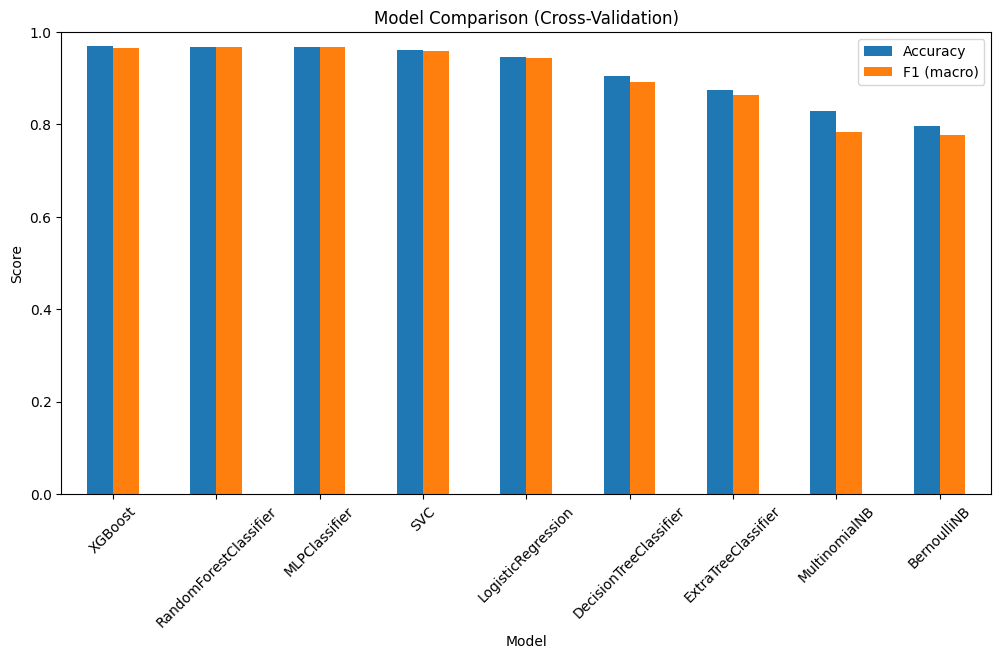

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

results = []

for name, model in models.items():
    try:
        # Cross-validation for Accuracy
        acc = cross_val_score(model, X, y, cv=5, scoring="accuracy").mean()

        # Cross-validation for Macro F1
        f1 = cross_val_score(model, X, y, cv=5, scoring="f1_macro").mean()

        results.append({
            "Model": name,
            "Accuracy": acc,
            "F1 (macro)": f1
        })
    except Exception as e:
        print(f"X {name} failed: {e}")

# Create dataframe
df_results = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print(df_results)

# Plot
df_results.plot(x="Model", y=["Accuracy", "F1 (macro)"], kind="bar", figsize=(12,6))
plt.title("Model Comparison (Cross-Validation)")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)  # keep scores between 0 and 1
plt.show()



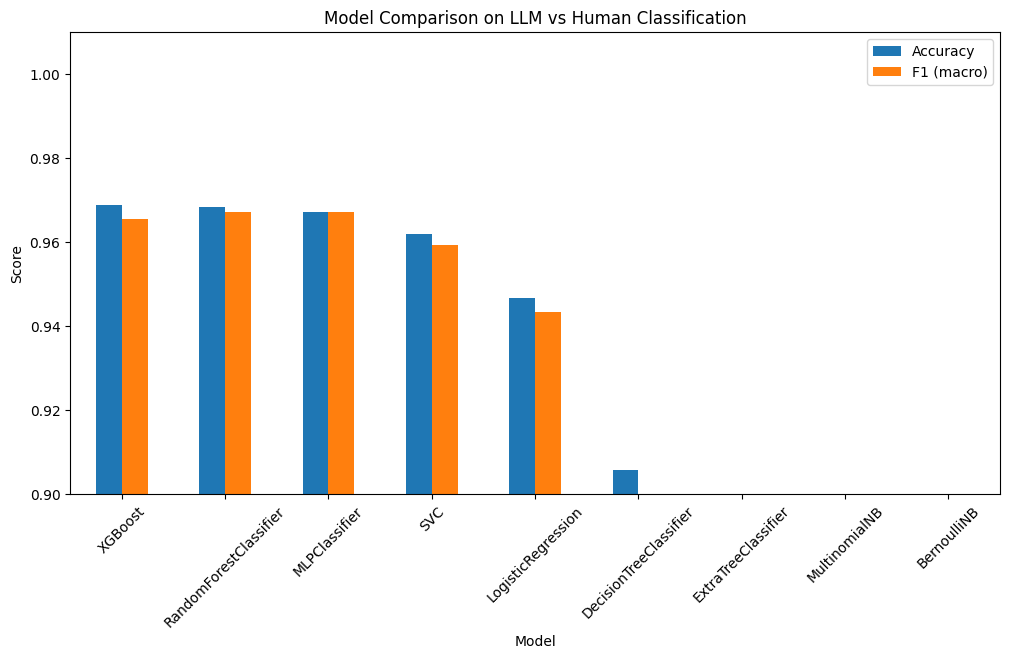

In [ ]:
df_results.plot(
    x="Model",
    y=["Accuracy", "F1 (macro)"],
    kind="bar",
    figsize=(12,6)
)
plt.title("Model Comparison on LLM vs Human Classification")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0.9, 1.01)  # zoom in to see small differences
plt.show()


In [43]:
best_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
best_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:46:36] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [44]:
import joblib

joblib.dump(best_model, 'ai_essay_classifier.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')


['tfidf_vectorizer.pkl']

In [45]:
!pip install gradio -q

import joblib
import re
import nltk
import string
import gradio as gr

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

lemmatizer = WordNetLemmatizer()

# --- Text Cleaning Function ---
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# --- Load Model and Vectorizer ---
model = joblib.load("ai_essay_classifier.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

# --- Prediction Function with Confidence ---
def classify(text):
    if text.strip() == "":
        return "⚠️ Please enter some text to classify."

    cleaned_input = clean_text(text)
    vectorized_input = vectorizer.transform([cleaned_input])

    proba = model.predict_proba(vectorized_input)[0]  # [prob_human, prob_ai]
    prediction = model.predict(vectorized_input)[0]

    if prediction == 0:
        label = "✅ This text looks like it was written by a **Human**."
        confidence = proba[0]
    else:
        label = "🤖 This text appears to be **AI-Generated**."
        confidence = proba[1]

    return f"{label}\n\n**Confidence:** {confidence*100:.1f}%"

# --- Gradio Interface ---
demo = gr.Interface(
    fn=classify,
    inputs=gr.Textbox(lines=7, placeholder="Paste your essay or paragraph here..."),
    outputs="markdown",
    title="📝 AI Essay Detector",
    description="Detect whether the given text was written by a Human or AI (with confidence score)."
)

demo.launch(share=True)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fa131e0b2478840aa2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
